In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("house_prices_practice.csv")

df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (300, 10)


In [5]:
print(df.columns)

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


In [7]:
print(df.isnull().sum())

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


In [8]:
df.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
X = df[
    [
        "OverallQual",
        "GrLivArea",
        "GarageCars",
        "TotalBsmtSF",
        "YearBuilt",
        "FullBath",
        "BedroomAbvGr",
        "LotArea"
    ]
]

y = df["SalePrice"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0            7       1560           0         1658       1969         2   
1            4       2827           2         1319       2012         3   
2            8       3920           0          841       2010         1   
3            5       3044           0         1058       1998         0   
4            7        801           1         2428       2020         0   

   BedroomAbvGr  LotArea  
0             1     8059  
1             4    13530  
2             4     9010  
3             4    13207  
4             1     9117  

Target:
0    177106
1    301044
2    360609
3    240556
4    193656
Name: SalePrice, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 8)
Testing data: (60, 8)


In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [13]:
y_pred = model.predict(X_test)

print("Predicted prices:")
print(y_pred[:10])

Predicted prices:
[239161.36318913 190489.66798468 398000.95746314 223169.46755225
 135188.39570786 180259.03980676 283708.27101141 204535.26547718
 205837.94173062 171505.33195999]


In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 12505.459264619487
R² Score: 0.9724369952260798


In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

        Feature   Coefficient
0   OverallQual  11914.688135
1     GrLivArea     55.410257
2    GarageCars  19109.641614
3   TotalBsmtSF     25.199018
4     YearBuilt    746.370978
5      FullBath  11040.343046
6  BedroomAbvGr   4812.061994
7       LotArea     -0.159522


In [16]:
print("Intercept:", model.intercept_)

Intercept: -1512820.5684315357


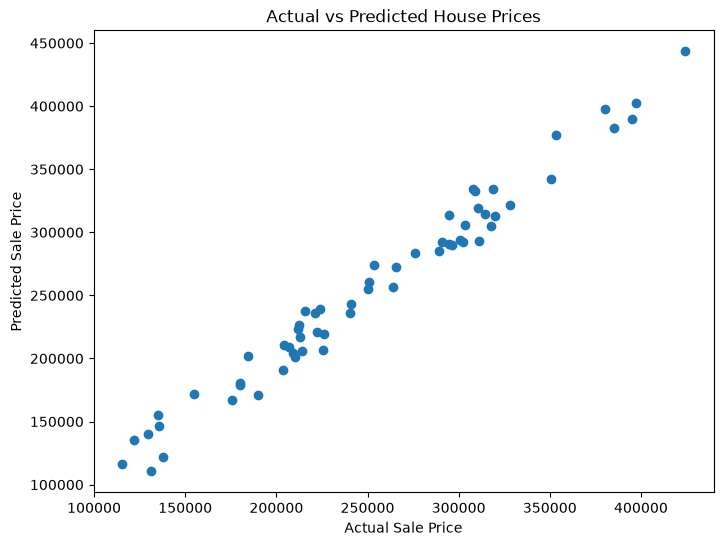

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [18]:
new_house = pd.DataFrame({
    "OverallQual": [7],
    "GrLivArea": [1800],
    "GarageCars": [2],
    "TotalBsmtSF": [1000],
    "YearBuilt": [2005],
    "FullBath": [2],
    "BedroomAbvGr": [3],
    "LotArea": [8000]
})

prediction = model.predict(new_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 265453.5194977068


In [19]:
import joblib

joblib.dump(model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [20]:
loaded_model = joblib.load("house_price_model.pkl")

test_prediction = loaded_model.predict(new_house)

print("Prediction using saved model:", test_prediction[0])

Prediction using saved model: 265453.5194977068
